### Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

#### Connection to WareHouse

In [5]:
SERVER = 'DESKTOP-1478HIH\\SQLEXPRESS'
DATABASE = 'oulad_warehouse'
USERNAME = 'BI_User'
PASSWORD = '123456'

connection_url = f"mssql+pyodbc://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}?driver=ODBC+Driver+17+for+SQL+Server"

engine = create_engine(connection_url)

try:
    with engine.connect() as connection:
        dim_modules     = pd.read_sql_query(text("SELECT * FROM dbo.Dim_Modules_Catalog"), connection)
        dim_students    = pd.read_sql_query(text("SELECT * FROM dbo.Dim_Students_Profile"), connection)
        dim_assessments = pd.read_sql_query(text("SELECT * FROM dbo.Dim_Assessments_Info"), connection)
        dim_vle         = pd.read_sql_query(text("SELECT * FROM dbo.Dim_Vle_Resources"), connection)
        fact_enrollment  = pd.read_sql_query(text("SELECT * FROM dbo.Fact_Enrollment"), connection)
        fact_scores      = pd.read_sql_query(text("SELECT * FROM dbo.Fact_Student_Scores"), connection)
        fact_clicks      = pd.read_sql_query(text("SELECT * FROM dbo.Fact_Student_Vle_Clicks"), connection)
    print('All Tables has loaded successfully')

except Exception as e:
    print('Something gone wrong')
    print(e)

All Tables has loaded successfully


## Oprational Report

Operational report Overview : Students Status


  Student_Status  Total_Students
0           Pass           12361
1      Withdrawn           10156
2           Fail            7052
3    Distinction            3024


Total students go to exam: 22437 students




C:\Users\LOQ\AppData\Local\Temp\ipykernel_24088\413756625.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Student_Status', y='Total_Students', data=status_count, palette='viridis')


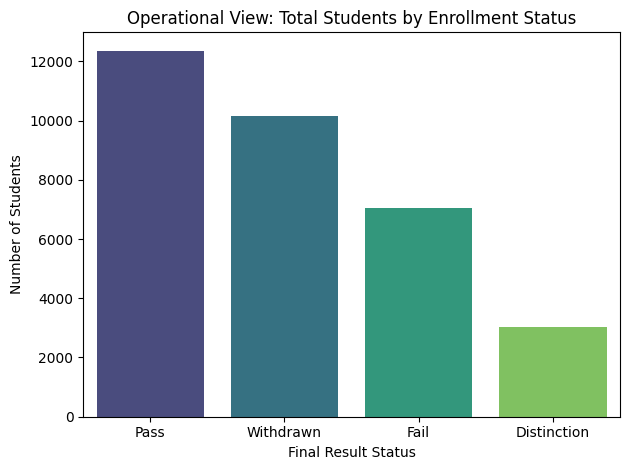

In [6]:
status_count = fact_enrollment['final_result'].value_counts().reset_index()
status_count.columns = ['Student_Status', 'Total_Students']

print('Operational report Overview : Students Status')
print("\n" + "="*50 + "\n")
print(status_count)
print("\n" + "="*50 + "\n")

eligable_students = fact_enrollment[fact_enrollment['is_active'] == 1]
print(f'Total students go to exam: {len(eligable_students)} students')
print("\n" + "="*50 + "\n")
sns.barplot(x='Student_Status', y='Total_Students', data=status_count, palette='viridis')

plt.title('Operational View: Total Students by Enrollment Status')
plt.xlabel('Final Result Status')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


Total Withdrawn Records to Cleanup: 10156 rows found.

First 5 records for Staff Action:
          Student_Key Module_Key  date_unregistration
6    AAA-2013J-106247  AAA-2013J                  175
20   AAA-2013J-129955  AAA-2013J                  135
23  AAA-2013J-1352868  AAA-2013J                  203
24   AAA-2013J-135335  AAA-2013J                   30
25   AAA-2013J-135400  AAA-2013J                  144




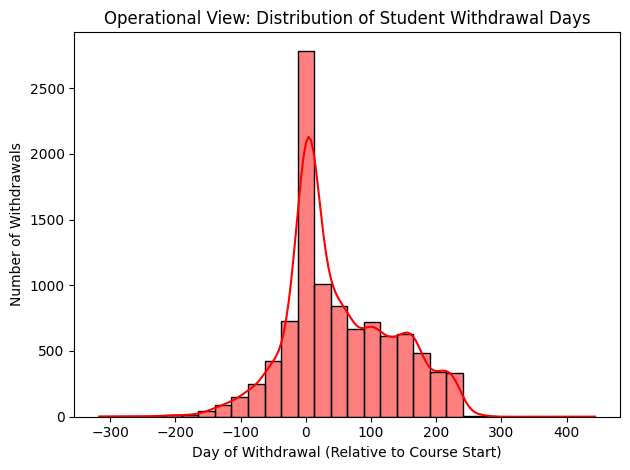

In [7]:
cleanup_df = fact_enrollment[fact_enrollment['final_result'] == 'Withdrawn'][['Student_Key', 'Module_Key', 'date_unregistration']]

print(f"Total Withdrawn Records to Cleanup: {len(cleanup_df)} rows found.")
print("\nFirst 5 records for Staff Action:")
print(cleanup_df.head())
print("\n" + "="*50 + "\n")

sns.histplot(data=cleanup_df, x='date_unregistration', bins=30, kde=True, color='red')

plt.title('Operational View: Distribution of Student Withdrawal Days')
plt.xlabel('Day of Withdrawal (Relative to Course Start)')
plt.ylabel('Number of Withdrawals')

plt.tight_layout()
plt.show()

Data Quality Report - Total Suspicious Rows Found: 0

Data Integrity Check Passed: All scores are perfectly within the 0-100 range.




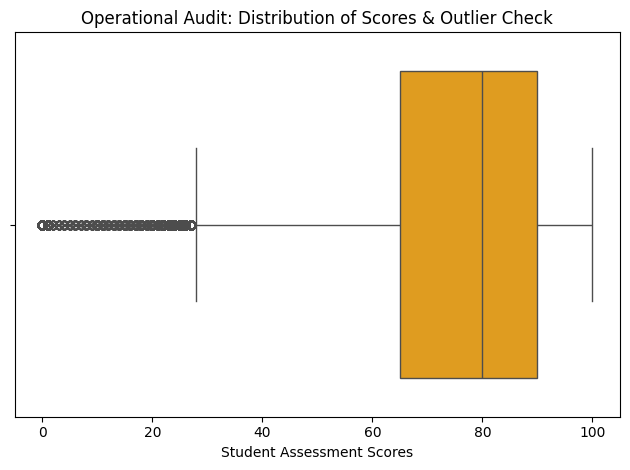

In [8]:
invalid_rows = fact_scores[(fact_scores['score'] < 0) | (fact_scores['score'] > 100) | (fact_scores['score'].isnull())]

print(f"Data Quality Report - Total Suspicious Rows Found: {len(invalid_rows)}")
if len(invalid_rows) > 0:
    print("\nMissing or Invalid Records for Staff Verification (Top 5):")
    print(invalid_rows[['Student_Key', 'id_assessment', 'score']].head())
else:
    print("\nData Integrity Check Passed: All scores are perfectly within the 0-100 range.")

print("\n" + "="*50 + "\n")


sns.boxplot(data=fact_scores, x='score', color='orange')

plt.title('Operational Audit: Distribution of Scores & Outlier Check')
plt.xlabel('Student Assessment Scores')

plt.tight_layout()
plt.show()

Operational Lookup for Student: BBB-2013B-12345

--- Personal Demographic Profile (From Dimension) ---
Empty DataFrame
Columns: [Student_Key, gender, region, highest_education]
Index: []


--- Academic Enrollment Records (From Fact) ---
Empty DataFrame
Columns: [Module_Key, days_enrolled, final_result]
Index: []




C:\Users\LOQ\AppData\Local\Temp\ipykernel_24088\4154162078.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dim_students, x='num_of_prev_attempts', palette='Blues')


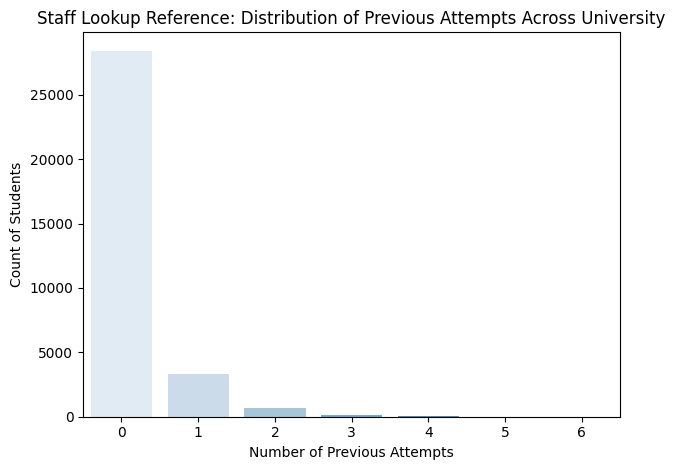

In [9]:
search_student_key = 'BBB-2013B-12345'
print(f"Operational Lookup for Student: {search_student_key}\n")

student_profile = dim_students[dim_students['Student_Key'] == search_student_key]
print("--- Personal Demographic Profile (From Dimension) ---")
print(student_profile[['Student_Key', 'gender', 'region', 'highest_education']])
print("\n" + "="*50 + "\n")

student_courses = fact_enrollment[fact_enrollment['Student_Key'] == search_student_key]
print("--- Academic Enrollment Records (From Fact) ---")
print(student_courses[['Module_Key', 'days_enrolled', 'final_result']])
print("\n" + "="*50 + "\n")

sns.countplot(data=dim_students, x='num_of_prev_attempts', palette='Blues')

plt.title('Staff Lookup Reference: Distribution of Previous Attempts Across University')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Count of Students')

plt.tight_layout()
plt.show()

In [1]:

status_count.to_excel('Student_Status_Summary.xlsx', index=False)


cleanup_df.to_excel('Withdrawn_Students_Cleanup_List.xlsx', index=False)


cleaned_operational_data = fact_enrollment.merge(dim_students, on='Student_Key', how='left')
cleaned_operational_data.to_excel('Cleaned_Operational_Data.xlsx', index=False)

print("Excel Data are ready")

NameError: name 'status_count' is not defined